# Kapitel 5 – Punktschätzung

Begleitendes Notebook zum Vorlesungsskript. Die Beispiele illustrieren:
1. Erwartungstreue von $\bar{X}$ und Bias der naiven Stichprobenvarianz $\tilde{S}^2$
2. Konsistenz: Konvergenz von $\bar{X}$ gegen $\mu$
3. Bias-Varianz-Tradeoff (MSE-Zerlegung)
4. Maximum-Likelihood-Schätzung (Binomial, Normal, Exponential)
5. Bayes-Schätzung: MAP mit Vorwissen

Alle Parameter sind frei anpassbar.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['mathtext.fontset'] = 'cm'
rng = np.random.default_rng(42)

## 1. Erwartungstreue von $\bar{X}$ und Bias von $\tilde{S}^2$

$\bar{X}$ ist erwartungstreu für $\mu$: $E(\bar{X})=\mu$.
Die naive Stichprobenvarianz $\tilde{S}^2 = \frac{1}{n}\sum (X_i-\bar{X})^2$ ist verzerrt: $E(\tilde{S}^2) = \frac{n-1}{n}\sigma^2$. Erwartungstreu ist $S^2$ mit Faktor $\frac{1}{n-1}$.

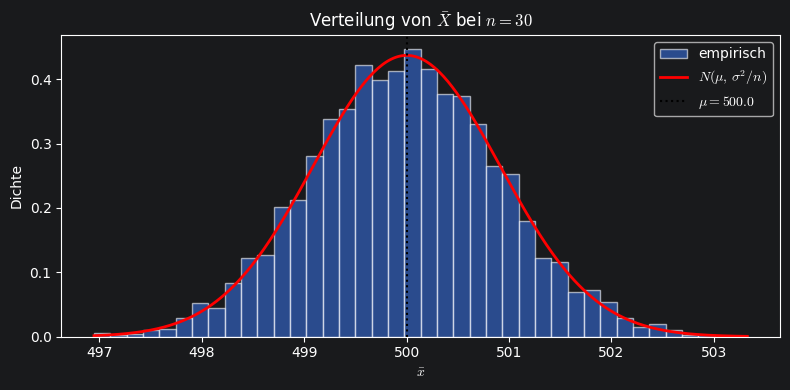

E(X-quer) empirisch = 499.983   (mu = 500.0)
E(S~^2)   empirisch = 24.365   (Erwartung (n-1)/n*sigma^2 = 24.167)
E(S^2)    empirisch = 25.205   (sigma^2 = 25.000)


In [16]:
# --- Parameter anpassen ---
mu, sigma = 500.0, 5.0
n = 30
anzahl_stichproben = 5000
# --------------------------

stichproben = rng.normal(mu, sigma, size=(anzahl_stichproben, n))
mittelwerte = stichproben.mean(axis=1)
naive_var   = stichproben.var(axis=1, ddof=0)   # 1/n
korr_var    = stichproben.var(axis=1, ddof=1)   # 1/(n-1)

fig, ax = plt.subplots(figsize=(8,4))
ax.hist(mittelwerte, bins=40, density=True, alpha=0.6, edgecolor='white', label='empirisch')
x = np.linspace(mittelwerte.min(), mittelwerte.max(), 300)
ax.plot(x, stats.norm.pdf(x, mu, sigma/np.sqrt(n)), 'r-', lw=2, label=r'$N(\mu,\,\sigma^2/n)$')
ax.axvline(mu, color='k', ls=':', label=fr'$\mu={mu}$')
ax.set_title(fr'Verteilung von $\bar{{X}}$ bei $n={n}$')
ax.set_xlabel(r'$\bar{x}$'); ax.set_ylabel('Dichte'); ax.legend()
plt.tight_layout(); plt.show()

print(f'E(X-quer) empirisch = {mittelwerte.mean():.3f}   (mu = {mu})')
print(f'E(S~^2)   empirisch = {naive_var.mean():.3f}   (Erwartung (n-1)/n*sigma^2 = {(n-1)/n*sigma**2:.3f})')
print(f'E(S^2)    empirisch = {korr_var.mean():.3f}   (sigma^2 = {sigma**2:.3f})')

## 2. Konsistenz von $\bar{X}$

Mit wachsendem Stichprobenumfang konvergiert $\bar{X}_n$ in Wahrscheinlichkeit gegen $\mu$.
Die Tschebyscheff-Schranke liefert $P(|\bar{X}-\mu|\geq\varepsilon) \leq \dfrac{\sigma^2}{n\,\varepsilon^2} \to 0$.

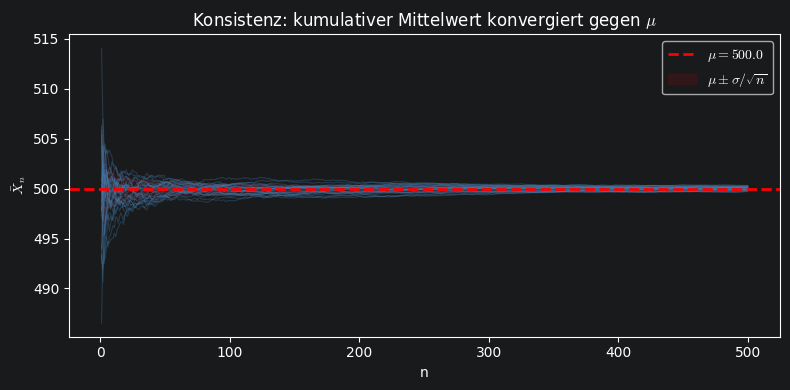

In [17]:
# --- Parameter anpassen ---
mu, sigma = 500.0, 5.0
n_max = 500
anzahl_pfade = 30
# --------------------------

ns = np.arange(1, n_max+1)
fig, ax = plt.subplots(figsize=(8,4))

for _ in range(anzahl_pfade):
    daten = rng.normal(mu, sigma, n_max)
    ax.plot(ns, np.cumsum(daten)/ns, color='steelblue', alpha=0.3, lw=0.8)

ax.axhline(mu, color='red', ls='--', lw=2, label=fr'$\mu={mu}$')
ax.fill_between(ns, mu-sigma/np.sqrt(ns), mu+sigma/np.sqrt(ns),
                color='red', alpha=0.1, label=r'$\mu \pm \sigma/\sqrt{n}$')
ax.set_title(r'Konsistenz: kumulativer Mittelwert konvergiert gegen $\mu$')
ax.set_xlabel('n'); ax.set_ylabel(r'$\bar{X}_n$'); ax.legend()
plt.tight_layout(); plt.show()

## 3. Bias-Varianz-Tradeoff (MSE-Zerlegung)

$\text{MSE}(\hat{\theta}) = \text{Var}(\hat{\theta}) + \text{Bias}(\hat{\theta})^2$.
Ein leicht verzerrter Schätzer mit kleiner Varianz kann einen kleineren Gesamtfehler haben als ein erwartungstreuer mit großer Varianz.

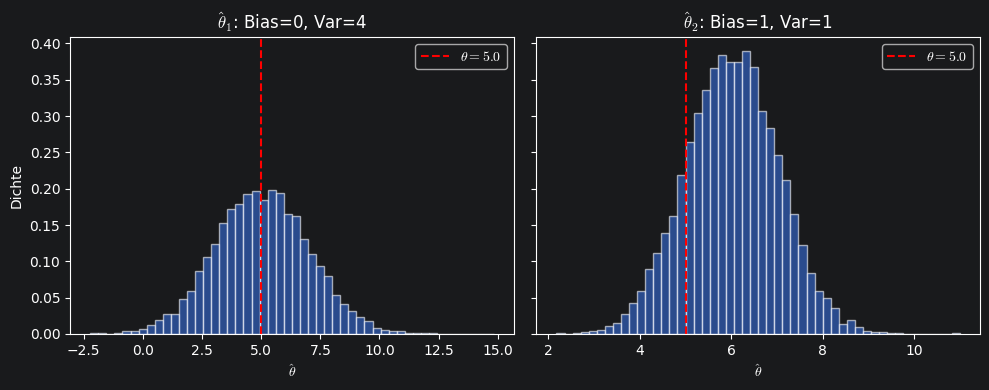

MSE(theta_1) = Var + Bias^2 = 4.0 + 0.0 = 4.0   (empirisch 3.928)
MSE(theta_2) = Var + Bias^2 = 1.0 + 1.0 = 2.0   (empirisch 2.045)


In [18]:
# --- Parameter anpassen ---
theta = 5.0
var1, bias1 = 4.0, 0.0   # erwartungstreu, hohe Varianz
var2, bias2 = 1.0, 1.0   # leicht verzerrt, geringe Varianz
B = 10000
# --------------------------

s1 = rng.normal(theta + bias1, np.sqrt(var1), B)
s2 = rng.normal(theta + bias2, np.sqrt(var2), B)

fig, axes = plt.subplots(1, 2, figsize=(10,4), sharey=True)
for ax, daten, titel in zip(axes, [s1, s2],
                             [fr'$\hat\theta_1$: Bias=0, Var={var1:g}',
                              fr'$\hat\theta_2$: Bias={bias2:g}, Var={var2:g}']):
    ax.hist(daten, bins=50, density=True, alpha=0.6, edgecolor='white')
    ax.axvline(theta, color='red', ls='--', label=fr'$\theta={theta}$')
    ax.set_title(titel); ax.set_xlabel(r'$\hat\theta$'); ax.legend()
axes[0].set_ylabel('Dichte')
plt.tight_layout(); plt.show()

mse1 = np.mean((s1-theta)**2)
mse2 = np.mean((s2-theta)**2)
print(f'MSE(theta_1) = Var + Bias^2 = {var1} + {bias1**2} = {var1+bias1**2}   (empirisch {mse1:.3f})')
print(f'MSE(theta_2) = Var + Bias^2 = {var2} + {bias2**2} = {var2+bias2**2}   (empirisch {mse2:.3f})')

## 4. Maximum-Likelihood-Schätzer

### 4a. Binomialverteilung: Ausschussanteil

Bei $n$ Bauteilen sind $k$ fehlerhaft. Für $X \sim B(n;\,p)$ gilt $L(p) \propto p^k(1-p)^{n-k}$ und damit $\hat{p}_{\text{ML}} = k/n$.

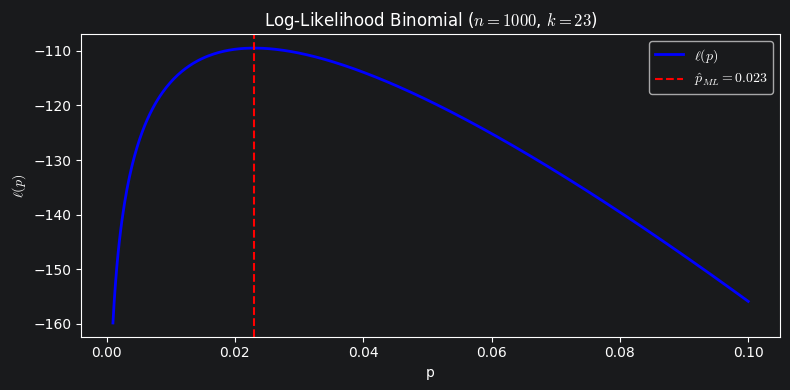

p_ML = k/n = 23/1000 = 0.0230


In [19]:
# --- Parameter anpassen ---
n_total = 1000
k_fehler = 23
# --------------------------

p = np.linspace(0.001, 0.1, 500)
log_lik = k_fehler*np.log(p) + (n_total-k_fehler)*np.log(1-p)
p_ml = k_fehler / n_total

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(p, log_lik, 'b-', lw=2, label=r'$\ell(p)$')
ax.axvline(p_ml, color='red', ls='--', label=fr'$\hat{{p}}_{{ML}}={p_ml:.3f}$')
ax.set_title(fr'Log-Likelihood Binomial ($n={n_total}$, $k={k_fehler}$)')
ax.set_xlabel('p'); ax.set_ylabel(r'$\ell(p)$'); ax.legend()
plt.tight_layout(); plt.show()

print(f'p_ML = k/n = {k_fehler}/{n_total} = {p_ml:.4f}')

### 4b. Normalverteilung: $\hat\mu_{\text{ML}}$ und $\hat\sigma^2_{\text{ML}}$

$\hat\mu_{\text{ML}} = \bar{X}$ und $\hat\sigma^2_{\text{ML}} = \frac{1}{n}\sum (X_i-\bar{X})^2$.
Achtung: $\hat\sigma^2_{\text{ML}}$ ist **nicht** erwartungstreu (siehe Abschnitt 1).

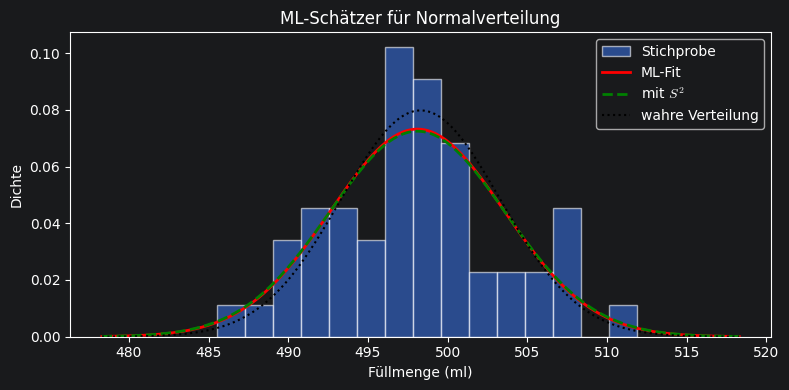

mu_ML       = 498.099      (wahr: 498.3)
sigma^2_ML  = 29.704  (wahr: 25.0)
S^2 (korr.) = 30.310


In [20]:
# --- Parameter anpassen ---
mu, sigma = 498.3, 5.0
n = 50
# --------------------------

daten = rng.normal(mu, sigma, n)
mu_ml = daten.mean()
sigma2_ml   = daten.var(ddof=0)
sigma2_korr = daten.var(ddof=1)

x = np.linspace(mu-4*sigma, mu+4*sigma, 300)
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(daten, bins=15, density=True, alpha=0.6, edgecolor='white', label='Stichprobe')
ax.plot(x, stats.norm.pdf(x, mu_ml, np.sqrt(sigma2_ml)),  'r-',  lw=2, label='ML-Fit')
ax.plot(x, stats.norm.pdf(x, mu_ml, np.sqrt(sigma2_korr)),'g--', lw=2, label=r'mit $S^2$')
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'k:', lw=1.5, label='wahre Verteilung')
ax.set_title('ML-Schätzer für Normalverteilung')
ax.set_xlabel('Füllmenge (ml)'); ax.set_ylabel('Dichte'); ax.legend()
plt.tight_layout(); plt.show()

print(f'mu_ML       = {mu_ml:.3f}      (wahr: {mu})')
print(f'sigma^2_ML  = {sigma2_ml:.3f}  (wahr: {sigma**2})')
print(f'S^2 (korr.) = {sigma2_korr:.3f}')

### 4c. Exponentialverteilung: $\hat\lambda_{\text{ML}}$

Aus $\ell(\lambda) = n\log\lambda - \lambda\sum x_i$ folgt $\hat\lambda_{\text{ML}} = 1/\bar{X}$.

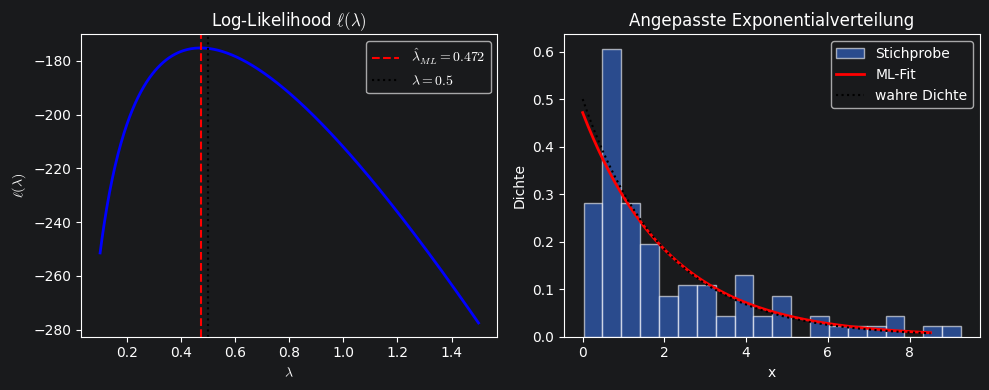

lambda_ML = 1/x-quer = 0.4716   (wahr: 0.5)


In [21]:
# --- Parameter anpassen ---
lam = 0.5
n = 100
# --------------------------

daten = rng.exponential(1/lam, n)
lam_ml = 1/daten.mean()

ls = np.linspace(0.1, 1.5, 400)
log_lik = n*np.log(ls) - ls*daten.sum()

fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].plot(ls, log_lik, 'b-', lw=2)
axes[0].axvline(lam_ml, color='red', ls='--', label=fr'$\hat\lambda_{{ML}}={lam_ml:.3f}$')
axes[0].axvline(lam, color='k', ls=':', label=fr'$\lambda={lam}$')
axes[0].set_title(r'Log-Likelihood $\ell(\lambda)$')
axes[0].set_xlabel(r'$\lambda$'); axes[0].set_ylabel(r'$\ell(\lambda)$'); axes[0].legend()

x = np.linspace(0, np.percentile(daten, 99), 200)
axes[1].hist(daten, bins=20, density=True, alpha=0.6, edgecolor='white', label='Stichprobe')
axes[1].plot(x, stats.expon.pdf(x, scale=1/lam_ml), 'r-', lw=2, label='ML-Fit')
axes[1].plot(x, stats.expon.pdf(x, scale=1/lam),    'k:', lw=1.5, label='wahre Dichte')
axes[1].set_title('Angepasste Exponentialverteilung')
axes[1].set_xlabel('x'); axes[1].set_ylabel('Dichte'); axes[1].legend()
plt.tight_layout(); plt.show()

print(f'lambda_ML = 1/x-quer = {lam_ml:.4f}   (wahr: {lam})')

## 5. Bayes-Schätzung: MAP-Schätzer

Vorwissen wird als gedachte Beobachtungen $k_0$, $n_0$ kodiert. Mit Likelihood $\propto p^k(1-p)^{n-k}$ und entsprechendem Prior ergibt sich:
$$\hat{p}_{\text{MAP}} = \frac{k+k_0}{n+n_0}$$
Die Posterior-Verteilung ist eine Beta-Verteilung.

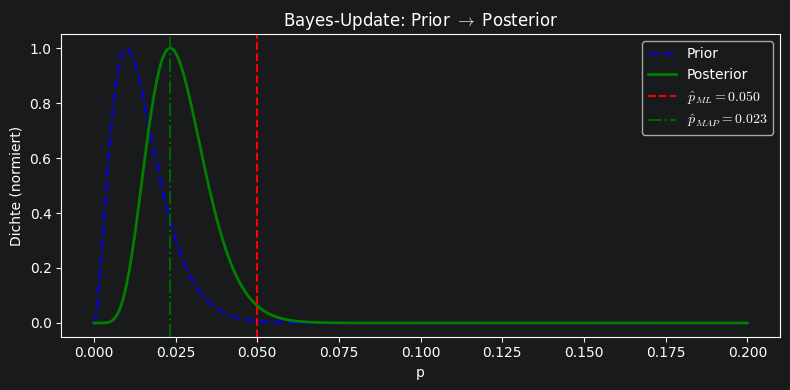

p_ML  = 5/100 = 0.0500
p_MAP = (5+2)/(100+200) = 0.0233
MAP wird durch Vorwissen Richtung Prior gezogen.


In [22]:
# --- Parameter anpassen ---
n, k = 100, 5         # Daten
n0, k0 = 200, 2       # Vorwissen (~1% Prior)
# --------------------------

p_ml  = k/n
p_map = (k+k0)/(n+n0)

p = np.linspace(0, 0.2, 500)
prior     = stats.beta.pdf(p, k0+1, (n0-k0)+1)
posterior = stats.beta.pdf(p, k+k0+1, (n-k)+(n0-k0)+1)

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(p, prior/prior.max(),         'b--', lw=2, alpha=0.7, label='Prior')
ax.plot(p, posterior/posterior.max(), 'g-',  lw=2, label='Posterior')
ax.axvline(p_ml,  color='red',       ls='--', label=fr'$\hat{{p}}_{{ML}}={p_ml:.3f}$')
ax.axvline(p_map, color='darkgreen', ls='-.', label=fr'$\hat{{p}}_{{MAP}}={p_map:.3f}$')
ax.set_title(r'Bayes-Update: Prior $\to$ Posterior')
ax.set_xlabel('p'); ax.set_ylabel('Dichte (normiert)'); ax.legend()
plt.tight_layout(); plt.show()

print(f'p_ML  = {k}/{n} = {p_ml:.4f}')
print(f'p_MAP = ({k}+{k0})/({n}+{n0}) = {p_map:.4f}')
print('MAP wird durch Vorwissen Richtung Prior gezogen.')

## Aufgaben zum Ausprobieren

1. Setze in Abschnitt 1 $n=5$ und vergleiche $E(\tilde{S}^2)$ mit $\sigma^2$ – wie groß ist der relative Bias?
2. Wähle in Abschnitt 2 ein größeres $\sigma$ – wie wirkt sich das auf die Konvergenzgeschwindigkeit aus?
3. Variiere in Abschnitt 3 $\text{Var}(\hat\theta_2)$ und $\text{Bias}(\hat\theta_2)$. Ab wann lohnt sich der verzerrte Schätzer nicht mehr?
4. Setze in Abschnitt 5 $n_0$ deutlich größer als $n$. Was passiert mit dem MAP-Schätzer?